# Temas Tratados en el Trabajo Práctico 3

* Estrategias de búsqueda local.

* Algoritmos Evolutivos.

* Problemas de Satisfacción de Restricciones.

# Ejercicios Teóricos

1. ¿Qué mecanismo de detención presenta el algoritmo de Ascensión de Colinas? Describa el problema que puede presentar este mecanismo y cómo se llaman las áreas donde ocurren estos problemas.


2. Describa las distintas heurísticas que se emplean en un problema de Satisfacción de Restricciones.

3. Se desea colorear el rompecabezas mostrado en la imagen con 7 colores distintos de manera que ninguna pieza tenga el mismo color que sus vecinas. Realice en una tabla el proceso de una búsqueda con Comprobación hacia Adelante empleando una heurística del Valor más Restringido.

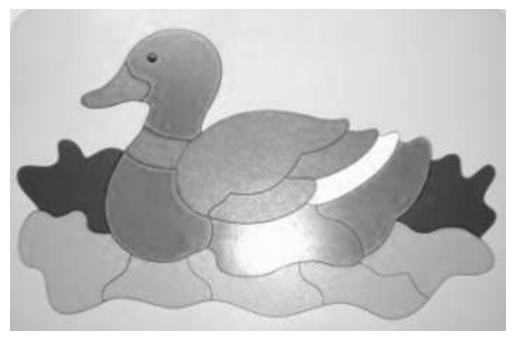

In [2]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1j94jFVxVG9y_ZnrMWOscQGb2MZ0Cdb3R"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

# Ejercicios de Implementación

4. Encuentre el máximo de la función $f(x) = \frac{\sin(x)}{x + 0.1}$ en $x \in [-10; -6]$ con un error menor a $0.1$ utilizando el algoritmo _hill climbing_.

5. Diseñe e implemente un algoritmo de Recocido Simulado para que juegue contra usted al Ta-te-ti. Varíe los valores de temperatura inicial entre partidas, ¿qué diferencia observa cuando la temperatura es más alta con respecto a cuando la temperatura es más baja?

Prompt utilizado: 
Actúa como un Ingeniero de Software experto en Inteligencia Artificial y Desarrollador Senior de Videojuegos en Python. 

Diseñar e implementar un videojuego interactivo de Ta-Te-Ti (Tres en Raya) en el cual un jugador humano se enfrente a un agente de Inteligencia Artificial que tome decisiones en tiempo real utilizando estrictamente el algoritmo de búsqueda local estocástica de Recocido Simulado (Simulated Annealing). El juego debe desarrollarse con una interfaz gráfica interactiva utilizando la biblioteca Pygame.

1. El Paisaje y Espacio de Estados: El tablero de 3x3 del Ta-Te-Ti. Cada estado candidato S_cand representa una casilla vacía del tablero donde el agente coloca su ficha 'O'.
2. Función de Costo (A minimizar): El costo de un movimiento S debe ser el valor negativo del tablero resultante. Diseña una función de evaluación heurística donde:
   - Victoria inmediata de la IA: Costo muy bajo (-100).
   - Bloqueo de victoria del Humano: Costo bajo (-50).
   - Creación de dos líneas de ataque (horca): Costo medio-bajo (-25).
   - Movimiento neutro/estándar: Costo neutro (0).
   - Permitir victoria del humano en el siguiente turno: Costo muy alto (+100).
3. Mecanismo de Selección (Criterio de Metrópolis): En cada turno de la IA, el algoritmo debe:
   - Seleccionar un movimiento S_act actual como punto de partida.
   - Generar un S_cand seleccionando de forma aleatoria otra casilla vacía disponible.
   - Calcular la diferencia de costo: Delta = Cost(S_cand) - Cost(S_act).
   - Si Delta < 0, el movimiento candidato S_cand es mejor, por lo que se acepta inmediatamente (S_act = S_cand).
   - Si Delta >= 0 (el movimiento es peor), se acepta S_cand solo con una probabilidad probabilística de e^(-Delta / T). Esto se logra generando un número aleatorio uniforme U(0,1); si U < e^(-Delta / T), se acepta S_cand.
4. Esquema de Enfriamiento: En cada turno, la IA debe ejecutar un bucle interno de "L" iteraciones a una temperatura dada "T". Después de cada lote de iteraciones, la temperatura se enfría geométricamente siguiendo T_new = T * alpha (con alpha entre 0.85 y 0.95).

1. Prohibido Minimax / Reglas Fijas: No utilices el algoritmo de búsqueda Minimax clásico, ni árboles de juego deterministas, ni tablas de decisión estáticas precalculadas. La IA debe pensar de forma dinámica en cada turno generando y evaluando de forma estocástica sus candidatos con Recocido Simulado.
2. Interfaz Pygame Requerida: No utilices la consola. Todo el juego debe correr en una ventana gráfica de Pygame interactiva y visualmente pulida (utiliza colores modernos, líneas limpias y animaciones sencillas si es posible).
3. Selector de Temperatura Inicial (T_0): El juego debe iniciar con una pantalla de bienvenida o menú interactivo que permita al usuario seleccionar o ingresar la temperatura inicial (T_0) para la IA antes de jugar. Debe incluir como mínimo tres modos preestablecidos fáciles de entender:
   - Modo Caótico / Fácil (T_0 = 500.0): La IA acepta casi cualquier movimiento malo debido al calor extremo, cometiendo errores obvios.
   - Modo Equilibrado / Medio (T_0 = 10.0): La IA juega de manera racional pero a veces arriesga o comete pequeñas imprecisiones.
   - Modo Voraz / Experto (T_0 = 0.01): Al estar casi congelada desde el inicio, la IA se comporta prácticamente como una búsqueda de ascensión de colinas pura (Hill-climbing), jugando de forma altamente competitiva y sin cometer fallos.
4. Modularidad y Robustez: El código debe ser modular, libre de bugs de concurrencia en el bucle principal de Pygame, y contener comentarios técnicos que expliquen la correspondencia física de las variables de temperatura, energía y Metrópolis con el código.

Entrega un único archivo de Python (.py) autónomo, limpio, listo para ser ejecutado con "python3".

In [ ]:
import math
import random
import sys
import pygame

# configuracion inicial de pygame, 
ANCHO, ALTO = 620, 820
FPS = 60

# --- Paleta de colores para la interfaz 
C_FONDO   = (13, 16, 25)
C_PANEL   = (23, 28, 42)
C_PANEL2  = (31, 38, 56)
C_GRID    = (52, 63, 88)
C_TEXTO   = (228, 233, 243)
C_TENUE   = (129, 142, 170)
C_HUMANO  = (78, 205, 196)    # 'X'
C_IA      = (244, 114, 182)   # 'O'
C_OK      = (74, 222, 128)
C_ALERTA  = (251, 191, 36)
C_ACENTO  = (99, 102, 241)
C_ROJO    = (248, 113, 113)

# --- Geometría del tablero ---
TAB_X, TAB_Y, TAB_LADO = 70, 185, 480
CELDA = TAB_LADO // 3

# --- parámetros del Recocido Simulado ---
ALPHA_DEF   = 0.90    # factor de enfriamiento geométrico (0.85 - 0.95)
L_ITER      = 20      # iteraciones 
LOTES_MAX   = 15      # cantidad de enfriamientos por turno
T_MIN       = 1e-3    # temperatura de congelamiento

MODOS = [
    ("FÁCIL",     500.0, "Calor extremo: acepta casi cualquier disparate."),
    ("MEDIO",  10.0, "Juega racional, pero a veces arriesga."),
    ("EXPERTO",       0.01, "Casi congelada: hill-climbing puro, implacable."),
]

# logica
VACIO, HUMANO, IA = " ", "X", "O"

LINEAS = [(0, 1, 2), (3, 4, 5), (6, 7, 8),
          (0, 3, 6), (1, 4, 7), (2, 5, 8),
          (0, 4, 8), (2, 4, 6)]

def tablero_nuevo():
    return [VACIO] * 9 #* copia referencias, no objetos

def casillas_vacias(t):
    return [i for i, v in enumerate(t) if v == VACIO] #enumerate(t) produce pares (índice, valor). La condición filtra por valor, pero lo que se guarda es el índice
                                                      # define el conjunto de microestados accesibles en el turno actual
def linea_ganadora(t, jugador):
    for linea in LINEAS:
        if all(t[i] == jugador for i in linea):
            return linea
    return None #all() tiene cortocircuito: si la primera casilla ya no es del jugador, no evalúa las otras dos. Y el return dentro del for corta el recorrido apenas encuentra una línea completa.

def hay_ganador(t, jugador):
    return linea_ganadora(t, jugador) is not None #compara identidad, no valor.

def tablero_lleno(t):
    return VACIO not in t #Si no queda ningún espacio, no hay jugadas posibles

def casillas_ganadoras(t, jugador):
    amenazas = set()
    for linea in LINEAS:
        vals = [t[i] for i in linea]
        if vals.count(jugador) == 2 and vals.count(VACIO) == 1:
            amenazas.add(linea[vals.index(VACIO)])
    return amenazas
 #sostiene toda la heurística de costo. Devuelve el conjunto de casillas donde jugador ganaría en su próxima jugada.

# funcion de costo --> energia 

def costo(t, mov):

    nuevo = list(t)
    nuevo[mov] = IA

    # Estado terminal favorable: la partida termina, nada puede empeorarlo.
    if hay_ganador(nuevo, IA):
        return -100.0
    e = 0.0

    # ¿La casilla elegida era justamente la que el humano necesitaba para ganar?
    if mov in casillas_ganadoras(t, HUMANO):
        e -= 50.0

    # ¿Quedan dos o más amenazas propias abiertas? (horca / doble ataque)
    if len(casillas_ganadoras(nuevo, IA)) >= 2:  #Dos o más es una horca (fork): vos solo podés tapar una por turno, así que la IA gana en la jugada siguiente sin importar qué hagas. −25.
        e -= 25.0

    # ¿El humano queda con una victoria servida en el turno siguiente?
    if len(casillas_ganadoras(nuevo, HUMANO)) > 0:
        e += 100.0

    return e

# recocido simulado
def recocido_simulado(t, T0, alpha=ALPHA_DEF, L=L_ITER, lotes=LOTES_MAX, t_min=T_MIN, rng=random):

    vacias = casillas_vacias(t)
    if not vacias:
        return None, {}

    energia = {m: costo(t, m) for m in vacias} #un caché de una sola evaluación por casilla, válido solo dentro de este turno. Se construye desde cero a partir del tablero real t

    # --- Estado inicial S_act: se parte de un microestado al azar ---
    s_act = rng.choice(vacias) #arranca en un microestado al azar.
    e_act = energia[s_act]
    s_mejor, e_mejor = s_act, e_act #Registro del mejor histórico. No se usa para decidir la jugada — se usa solo para la telemetría, para poder mostrar en pantalla si la IA terminó en el óptimo o se quedó calentada en un estado peor
  
    T = float(T0)
    aceptados = mejoras = saltos_metropolis = evaluados = 0
    historial_T = []

    for _ in range(lotes): #_ como variable de descarte: el índice no se usa, solo importa la cantidad de repeticiones. Es convención de Python, no sintaxis especial
        if T < t_min:
            break
        # ----  L iteraciones a temperatura T constante ----------
        for _ in range(L):
            if len(vacias) > 1:
                s_cand = rng.choice([m for m in vacias if m != s_act])
            else:
                s_cand = s_act
            e_cand = energia[s_cand]
            evaluados += 1

            # ΔE = E(S_cand) - E(S_act)
            delta = e_cand - e_act

            if delta < 0:
                s_act, e_act = s_cand, e_cand
                aceptados += 1
                mejoras += 1
            else:
                # CRITERIO DE METRÓPOLIS  P = exp(-ΔE/kT).
                p = math.exp(-delta / max(T, 1e-12))
                if rng.random() < p: #es el sorteo: un uniforme U(0,1) comparado contra la probabilidad.
                    s_act, e_act = s_cand, e_cand
                    aceptados += 1
                    saltos_metropolis += 1

            if e_act < e_mejor:
                s_mejor, e_mejor = s_act, e_act

        historial_T.append(T)
        T *= alpha

    tel = {  #Ese campo es lo que muestra en pantalla si la IA terminó en el óptimo o quedó "caliente"
        "T0": float(T0),
        "T_final": T,
        "aceptados": aceptados,
        "mejoras": mejoras,
        "metropolis": saltos_metropolis,
        "evaluados": evaluados,
        "energia_elegida": e_act,
        "energia_optima": e_mejor,
        "optimo_alcanzado": abs(e_act - e_mejor) < 1e-9,
        "lotes": len(historial_T),
    }
    return s_act, tel

#Esta sección es toda la parte visual. Son funciones que ya me dejan escribir texto, dibujar cuadritos redondeados, animar las fichas, NO LA LÓGICA DEL JUEGO
def fuente(tam, negrita=False):
    return pygame.font.SysFont(
        "segoeui,dejavusans,verdana,arial,helvetica", tam, bold=negrita)


def escribir(sup, msg, f, color, centro=None, topleft=None, midleft=None):
    img = f.render(msg, True, color)
    rect = img.get_rect()
    if centro:
        rect.center = centro
    elif topleft:
        rect.topleft = topleft
    elif midleft:
        rect.midleft = midleft
    sup.blit(img, rect)
    return rect


def panel(sup, rect, color=C_PANEL, radio=16, borde=None, grosor_borde=2):
    pygame.draw.rect(sup, color, rect, border_radius=radio)
    if borde:
        pygame.draw.rect(sup, borde, rect, grosor_borde, border_radius=radio)


def suavizar(p):
    """Ease-out cúbico para animaciones."""
    p = max(0.0, min(1.0, p))
    return 1.0 - (1.0 - p) ** 3


def dibujar_x(sup, centro, radio, p, color, grosor=13):
    cx, cy = centro
    p1 = min(1.0, p / 0.55)
    if p1 > 0.01:
        pygame.draw.line(sup, color, (cx - radio, cy - radio),
                         (cx - radio + 2 * radio * p1, cy - radio + 2 * radio * p1), grosor)
    p2 = min(1.0, max(0.0, (p - 0.45) / 0.55))
    if p2 > 0.01:
        pygame.draw.line(sup, color, (cx + radio, cy - radio),
                         (cx + radio - 2 * radio * p2, cy - radio + 2 * radio * p2), grosor)


def dibujar_o(sup, centro, radio, p, color, grosor=13):
    if p >= 0.995:
        pygame.draw.circle(sup, color, centro, radio, grosor)
        return
    ang = 2 * math.pi * p
    if ang < 0.05:
        return
    rect = pygame.Rect(centro[0] - radio, centro[1] - radio, radio * 2, radio * 2)
    pygame.draw.arc(sup, color, rect, -math.pi / 2 - ang, -math.pi / 2, grosor)


class Boton:
    def __init__(self, rect, titulo, subtitulo="", color=C_ACENTO, valor=None):
        self.rect = pygame.Rect(rect)
        self.titulo = titulo
        self.subtitulo = subtitulo
        self.color = color
        self.valor = valor

    def dibujar(self, sup, mouse, f_tit, f_sub):
        hover = self.rect.collidepoint(mouse)
        fondo = C_PANEL2 if hover else C_PANEL
        panel(sup, self.rect, fondo, radio=14,
              borde=self.color, grosor_borde=3 if hover else 2)
        if self.subtitulo:
            escribir(sup, self.titulo, f_tit, C_TEXTO,
                     midleft=(self.rect.x + 22, self.rect.centery - 13))
            escribir(sup, self.subtitulo, f_sub, C_TENUE,
                     midleft=(self.rect.x + 22, self.rect.centery + 14))
        else:
            escribir(sup, self.titulo, f_tit, C_TEXTO, centro=self.rect.center)

    def clic(self, pos):
        return self.rect.collidepoint(pos)


#El cerebro del juego. Decide de quién es el turno, cuándo terminó la partida y quién ganó. También escucha los clics y las teclas, y dibuja las dos pantallas (el menú y el tablero). Es la parte que conecta el algoritmo con lo que se ve

class Juego:
    DUR_FICHA = 0.28      # s de animación de la ficha
    DUR_LINEA = 0.45      # s de animación de la línea ganadora
    PAUSA_IA = 0.65       # s de "pensando" antes de aplicar la jugada

    def __init__(self):
        self.f_titan = fuente(46, True)
        self.f_tit   = fuente(30, True)
        self.f_med   = fuente(21, True)
        self.f_txt   = fuente(16)
        self.f_txtb  = fuente(16, True)
        self.f_min   = fuente(13)
        self.f_mono  = fuente(15, True)

        # --- Estado global ---
        self.estado = "MENU"          # MENU | JUGANDO | FIN
        self.T0 = 10.0
        self.modo_nombre = "MEDIO"
        self.humano_empieza = True
        self.marcador = {"humano": 0, "ia": 0, "empate": 0}

        # --- Entrada de T0 personalizada ---
        self.caja_T = pygame.Rect(70, 585, 300, 52)
        self.entrada_activa = False
        self.entrada_txt = ""
        self.error_txt = ""
        self.cursor_t = 0.0

        # --- Botones ---
        self.btn_modos = []
        for i, (nombre, t0, desc) in enumerate(MODOS):
            color = [C_OK, C_ALERTA, C_ROJO][i]
            self.btn_modos.append(
                Boton((70, 250 + i * 100, 480, 86),
                      f"{nombre}   ·   T₀ = {t0}", desc, color, valor=(nombre, t0)))
        self.btn_jugar   = Boton((390, 585, 160, 52), "JUGAR", color=C_ACENTO)
        self.btn_orden   = Boton((70, 660, 480, 44), "", color=C_GRID)
        self.btn_reiniciar = Boton((40, 772, 262, 40), "REINICIAR", color=C_ACENTO)
        self.btn_menu      = Boton((318, 772, 262, 40), "MENÚ", color=C_GRID)

        self.reiniciar_partida()

    # ---------------------------------------------------------------- partida
    def reiniciar_partida(self):
        self.tablero = tablero_nuevo()
        self.anim = {}                # Tablero limpio y animaciones a cero.
        self.linea_gan = None
        self.anim_linea = 0.0
        self.turno = HUMANO if self.humano_empieza else IA
        self.reloj_ia = self.PAUSA_IA
        self.tel = None
        self.mensaje_fin = ""
        self.color_fin = C_TEXTO
        self.ultimo_mov_ia = None
        if self.estado != "MENU":
            self.estado = "JUGANDO"

    def animaciones_activas(self):
        return any(p < 1.0 for p in self.anim.values())  #Se usa como bloqueo de entrada. Mientras una ficha se está dibujando, no aceptás clics ni dejás jugar a la IA. Evita el bug de que hagas doble clic rápido y metas dos jugadas antes de que la primera se procese

    def aplicar_jugada(self, idx, jugador):
        self.tablero[idx] = jugador
        self.anim[idx] = 0.0
        self.verificar_fin()
        if self.estado == "JUGANDO":
            self.turno = IA if jugador == HUMANO else HUMANO
            self.reloj_ia = self.PAUSA_IA

    def verificar_fin(self):
        for jug in (HUMANO, IA):
            linea = linea_ganadora(self.tablero, jug)
            if linea:
                self.linea_gan = linea
                self.anim_linea = 0.0
                self.estado = "FIN"
                if jug == HUMANO:
                    self.mensaje_fin = "¡GANASTE!  La IA se quedó en un mínimo local."
                    self.color_fin = C_HUMANO
                    self.marcador["humano"] += 1
                else:
                    self.mensaje_fin = "GANÓ LA IA.  El recocido encontró el pozo de energía."
                    self.color_fin = C_IA
                    self.marcador["ia"] += 1
                return
        if tablero_lleno(self.tablero):
            self.estado = "FIN"
            self.mensaje_fin = "EMPATE.  Sistema en equilibrio."
            self.color_fin = C_TENUE
            self.marcador["empate"] += 1

    def turno_de_la_ia(self):
        mov, tel = recocido_simulado(self.tablero, self.T0)
        if mov is None:
            return
        self.tel = tel
        self.ultimo_mov_ia = mov
        self.aplicar_jugada(mov, IA)

    def iniciar_juego(self, nombre, t0):
        self.modo_nombre = nombre
        self.T0 = t0
        self.estado = "JUGANDO"
        self.error_txt = ""
        self.reiniciar_partida()

    # eventos
    def manejar_eventos(self, eventos):
        for ev in eventos:
            if ev.type == pygame.KEYDOWN and ev.key == pygame.K_ESCAPE:
                if self.estado == "MENU":
                    pygame.quit()
                    sys.exit()
                self.estado = "MENU"
                continue

            if self.estado == "MENU":
                self._eventos_menu(ev)
            else:
                self._eventos_juego(ev)

    def _eventos_menu(self, ev):
        if ev.type == pygame.MOUSEBUTTONDOWN and ev.button == 1:
            self.entrada_activa = self.caja_T.collidepoint(ev.pos)
            for b in self.btn_modos:
                if b.clic(ev.pos):
                    self.iniciar_juego(*b.valor)
                    return
            if self.btn_orden.clic(ev.pos):
                self.humano_empieza = not self.humano_empieza
                return
            if self.btn_jugar.clic(ev.pos):
                self._validar_T_personalizada()
                return

        if ev.type == pygame.KEYDOWN and self.entrada_activa:
            if ev.key == pygame.K_BACKSPACE:
                self.entrada_txt = self.entrada_txt[:-1]
            elif ev.key in (pygame.K_RETURN, pygame.K_KP_ENTER):
                self._validar_T_personalizada()
            elif ev.unicode in "0123456789." and len(self.entrada_txt) < 10:
                self.entrada_txt += ev.unicode

    def _validar_T_personalizada(self):
        try:
            t0 = float(self.entrada_txt)
            if t0 <= 0:
                raise ValueError
            self.iniciar_juego("PERSONALIZADO", t0)
        except ValueError:
            self.error_txt = "Ingresá una temperatura T₀ numérica y mayor que 0."

    def _eventos_juego(self, ev):
        if ev.type != pygame.MOUSEBUTTONDOWN or ev.button != 1:
            return
        if self.btn_reiniciar.clic(ev.pos):
            self.reiniciar_partida()
            return
        if self.btn_menu.clic(ev.pos):
            self.estado = "MENU"
            return

        if self.estado == "JUGANDO" and self.turno == HUMANO and not self.animaciones_activas():
            idx = self.celda_en(ev.pos)
            if idx is not None and self.tablero[idx] == VACIO:
                self.aplicar_jugada(idx, HUMANO)

    @staticmethod
    def celda_en(pos):
        x, y = pos
        if not (TAB_X <= x < TAB_X + TAB_LADO and TAB_Y <= y < TAB_Y + TAB_LADO):
            return None
        return ((y - TAB_Y) // CELDA) * 3 + ((x - TAB_X) // CELDA)

    # TURNO DE LA IA
    def actualizar(self, dt):
        self.cursor_t += dt

        for idx in list(self.anim):
            if self.anim[idx] < 1.0:
                self.anim[idx] = min(1.0, self.anim[idx] + dt / self.DUR_FICHA)

        if self.linea_gan and self.anim_linea < 1.0:
            self.anim_linea = min(1.0, self.anim_linea + dt / self.DUR_LINEA)

        # Turno de la IA: temporizado por dt
        if self.estado == "JUGANDO" and self.turno == IA and not self.animaciones_activas():
            self.reloj_ia -= dt
            if self.reloj_ia <= 0:
                self.turno_de_la_ia()
 #Las funciones _dibujar_* son puro renderizado: leen el estado y lo pintan en pantalla, sin modificar nada
    #  dibujar
    def dibujar(self, sup):
        sup.fill(C_FONDO)
        if self.estado == "MENU":
            self._dibujar_menu(sup)
        else:
            self._dibujar_juego(sup)

    # ---- MENÚ pinta la pantalla de bienvenida: el título, los tres botones de modo, el campo para escribir una T₀ propia, el selector de quién arranca y el pie con los parámetros del algoritmo 
    def _dibujar_menu(self, sup):
        mouse = pygame.mouse.get_pos()
        escribir(sup, "TA-TE-TI", self.f_titan, C_TEXTO, centro=(ANCHO // 2, 92))
        escribir(sup, "Agente de Recocido Simulado  ·  Búsqueda Local Estocástica",
                 self.f_txtb, C_ACENTO, centro=(ANCHO // 2, 140))
        escribir(sup, "Elegí la temperatura inicial T₀: define cuánto ‘calor’ (error) tolera la IA.",
                 self.f_txt, C_TENUE, centro=(ANCHO // 2, 172))

        for b in self.btn_modos:
            b.dibujar(sup, mouse, self.f_txtb, self.f_min)

        escribir(sup, "…o ingresá tu propia T₀:", self.f_txt, C_TENUE, topleft=(72, 558))
        activa = self.entrada_activa
        panel(sup, self.caja_T, C_PANEL, 14, C_ACENTO if activa else C_GRID, 3 if activa else 2)
        txt = self.entrada_txt if self.entrada_txt else "ej. 2.5"
        color = C_TEXTO if self.entrada_txt else C_TENUE
        escribir(sup, txt, self.f_med, color, midleft=(self.caja_T.x + 18, self.caja_T.centery))
        if activa and int(self.cursor_t * 2) % 2 == 0:
            w = self.f_med.size(self.entrada_txt)[0]
            x = self.caja_T.x + 20 + w
            pygame.draw.line(sup, C_ACENTO, (x, self.caja_T.y + 13), (x, self.caja_T.bottom - 13), 2)
        self.btn_jugar.dibujar(sup, mouse, self.f_txtb, self.f_min)

        self.btn_orden.titulo = ("COMIENZA:  VOS  (X)" if self.humano_empieza
                                 else "COMIENZA:  LA IA  (O)")
        self.btn_orden.color = C_HUMANO if self.humano_empieza else C_IA
        self.btn_orden.dibujar(sup, mouse, self.f_txtb, self.f_min)

        if self.error_txt:
            escribir(sup, self.error_txt, self.f_min, C_ROJO, centro=(ANCHO // 2, 722))

        escribir(sup, f"Enfriamiento geométrico:  T ← T · α    con α = {ALPHA_DEF}",
                 self.f_min, C_TENUE, centro=(ANCHO // 2, 752))
        escribir(sup, f"{L_ITER} iteraciones por lote  ·  {LOTES_MAX} lotes por turno  "
                      f"·  Metrópolis  P = e^(-ΔE/T)",
                 self.f_min, C_TENUE, centro=(ANCHO // 2, 774))
        escribir(sup, "ESC para salir", self.f_min, C_GRID, centro=(ANCHO // 2, 798))

    # ---- JUEGO _dibujar_juego es el coordinador. No dibuja nada por sí mismo, solo llama a las otras tres en orden (cabecera, tablero, telemetría) más los dos botones de abajo
    def _dibujar_juego(self, sup):
        mouse = pygame.mouse.get_pos()
        self._dibujar_cabecera(sup)
        self._dibujar_tablero(sup, mouse)
        self._dibujar_telemetria(sup)
        self.btn_reiniciar.dibujar(sup, mouse, self.f_txtb, self.f_min)
        self.btn_menu.dibujar(sup, mouse, self.f_txtb, self.f_min)
    #_dibujar_cabecera es la franja superior: título, la cápsula con el modo y T₀, el indicador de turno, y el marcador acumulado
    def _dibujar_cabecera(self, sup):
        escribir(sup, "TA-TE-TI", self.f_tit, C_TEXTO, centro=(ANCHO // 2, 34))
        chip = f"{self.modo_nombre}   ·   T₀ = {self.T0:g}   ·   α = {ALPHA_DEF}"
        w = self.f_min.size(chip)[0] + 34
        r = pygame.Rect(0, 0, w, 28)
        r.center = (ANCHO // 2, 74)
        panel(sup, r, C_PANEL, 14, C_ACENTO, 1)
        escribir(sup, chip, self.f_min, C_ACENTO, centro=r.center)

        if self.estado == "FIN":
            escribir(sup, self.mensaje_fin, self.f_txtb, self.color_fin, centro=(ANCHO // 2, 114))
        elif self.turno == HUMANO:
            escribir(sup, "TU TURNO  (X)", self.f_med, C_HUMANO, centro=(ANCHO // 2, 114))
        else:
            puntos = "." * (1 + int(self.cursor_t * 3) % 3)
            escribir(sup, f"LA IA ESTÁ ENFRIANDO SU BÚSQUEDA{puntos}", self.f_med, C_IA,
                     centro=(ANCHO // 2, 114))

        m = self.marcador
        escribir(sup, f"Vos {m['humano']}   ·   IA {m['ia']}   ·   Empates {m['empate']}",
                 self.f_min, C_TENUE, centro=(ANCHO // 2, 152))
   #_dibujar_tablero es el centro: el panel de fondo, el resaltado de la celda bajo el cursor, la grilla, las fichas con su animación, y la línea ganadora
    def _dibujar_tablero(self, sup, mouse):
        panel(sup, pygame.Rect(TAB_X - 12, TAB_Y - 12, TAB_LADO + 24, TAB_LADO + 24),
              C_PANEL, 22)

  
        if self.estado == "JUGANDO" and self.turno == HUMANO:
            idx = self.celda_en(mouse)
            if idx is not None and self.tablero[idx] == VACIO:
                f, c = divmod(idx, 3)
                r = pygame.Rect(TAB_X + c * CELDA + 6, TAB_Y + f * CELDA + 6,
                                CELDA - 12, CELDA - 12)
                panel(sup, r, C_PANEL2, 14)

        # Grilla
        for i in (1, 2):
            x = TAB_X + i * CELDA
            pygame.draw.line(sup, C_GRID, (x, TAB_Y + 14), (x, TAB_Y + TAB_LADO - 14), 4)
            y = TAB_Y + i * CELDA
            pygame.draw.line(sup, C_GRID, (TAB_X + 14, y), (TAB_X + TAB_LADO - 14, y), 4)

        # Fichas
        for idx, val in enumerate(self.tablero):
            if val == VACIO:
                continue
            f, c = divmod(idx, 3)
            centro = (TAB_X + c * CELDA + CELDA // 2, TAB_Y + f * CELDA + CELDA // 2)
            p = suavizar(self.anim.get(idx, 1.0))
            if val == HUMANO:
                dibujar_x(sup, centro, 44, p, C_HUMANO)
            else:
                dibujar_o(sup, centro, 46, p, C_IA)

        # Línea ganadora animada
        if self.linea_gan:
            a, _, b = self.linea_gan
            fa, ca = divmod(a, 3)
            fb, cb = divmod(b, 3)
            p1 = (TAB_X + ca * CELDA + CELDA // 2, TAB_Y + fa * CELDA + CELDA // 2)
            p2 = (TAB_X + cb * CELDA + CELDA // 2, TAB_Y + fb * CELDA + CELDA // 2)
            k = suavizar(self.anim_linea)
            fin = (p1[0] + (p2[0] - p1[0]) * k, p1[1] + (p2[1] - p1[1]) * k)
            color = C_HUMANO if self.tablero[a] == HUMANO else C_IA
            pygame.draw.line(sup, color, p1, fin, 9)

    def _dibujar_telemetria(self, sup): #es el panel de abajo con los datos del último recocido
        r = pygame.Rect(40, 682, 540, 78)
        panel(sup, r, C_PANEL, 16, C_GRID, 1)

        if not self.tel:
            escribir(sup, "Telemetría del recocido: esperando el primer turno de la IA…", self.f_min, C_TENUE, centro=r.center)
            return

        t = self.tel
        escribir(sup, "ÚLTIMA DECISIÓN DE LA IA", self.f_min, C_TENUE, topleft=(r.x + 18, r.y + 10))

        e = t["energia_elegida"]
        col_e = C_OK if e < 0 else (C_ROJO if e > 0 else C_TENUE)
        escribir(sup, f"E = {e:+.0f}", self.f_mono, col_e, topleft=(r.x + 18, r.y + 32))
        escribir(sup, "óptimo" if t["optimo_alcanzado"] else "subóptimo (calor)",
                 self.f_min, col_e, topleft=(r.x + 18, r.y + 54))

        escribir(sup, f"T_final = {t['T_final']:.3g}", self.f_mono, C_ALERTA,
                 topleft=(r.x + 150, r.y + 32))
        escribir(sup, f"{t['lotes']} enfriamientos", self.f_min, C_TENUE,
                 topleft=(r.x + 150, r.y + 54))

        escribir(sup, f"aceptados {t['aceptados']}/{t['evaluados']}", self.f_mono, C_TEXTO,
                 topleft=(r.x + 310, r.y + 32))
        escribir(sup, f"saltos Metrópolis: {t['metropolis']}", self.f_min, C_TENUE,
                 topleft=(r.x + 310, r.y + 54))

        # Barra logarítmica de temperatura 
        barra = pygame.Rect(r.right - 18 - 120, r.y + 12, 120, 10)
        panel(sup, barra, C_PANEL2, 5)
        k = (math.log10(max(t["T_final"], 1e-3)) + 3) / 6.0
        k = max(0.02, min(1.0, k))
        panel(sup, pygame.Rect(barra.x, barra.y, int(barra.w * k), barra.h), C_ALERTA, 5)
 #MAIN
def main():
    pygame.init()
    pygame.display.set_caption("Ta-Te-Ti")
    pantalla = pygame.display.set_mode((ANCHO, ALTO))
    reloj = pygame.time.Clock()
    juego = Juego()

    while True:
        dt = reloj.tick(FPS) / 1000.0     # dt real: toda la lógica es temporizada
        eventos = pygame.event.get()
        for ev in eventos:
            if ev.type == pygame.QUIT:
                pygame.quit()
                sys.exit()

        juego.manejar_eventos(eventos)
        juego.actualizar(dt)
        juego.dibujar(pantalla)
        pygame.display.flip()


if __name__ == "__main__":
    main()

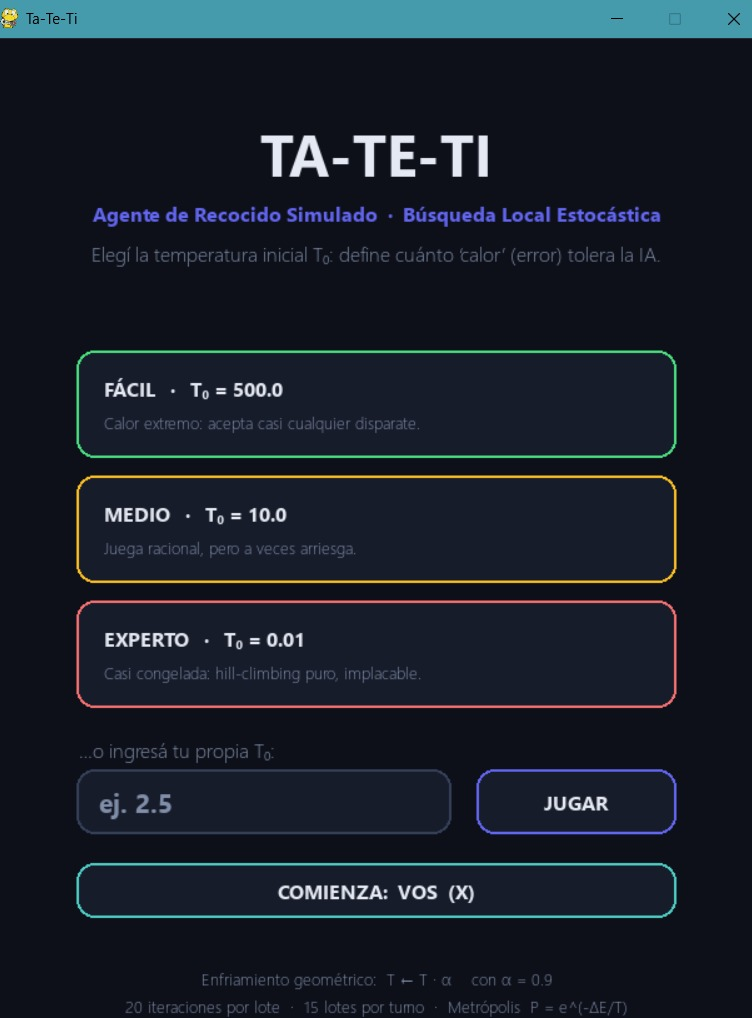

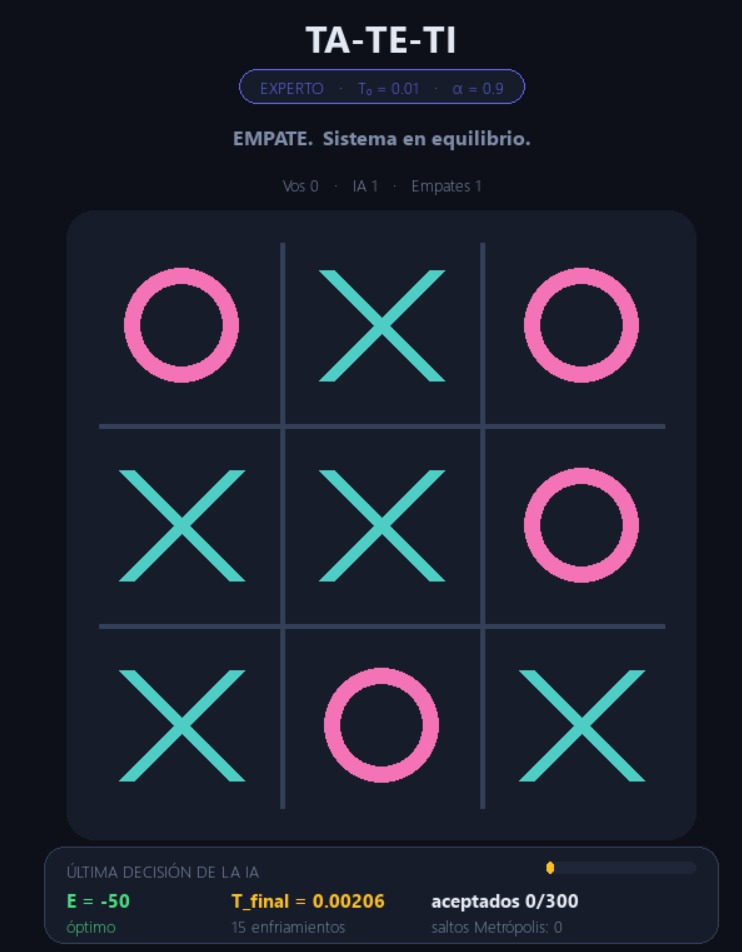


6. Diseñe e implemente un algoritmo genético para cargar una grúa con $n=10\;cajas$ que puede soportar un peso máximo $C=1000\;kg$. Cada caja *j* tiene asociado un precio $p_j$ y un peso $w_j$ como se indica en la tabla de abajo, de manera que el algoritmo debe ser capaz de maximizar el precio sin superar el límite de carga.

<table><tr><td>Elemento ($j$)</td><td>1</td><td>2</td><td>3</td><td>4</td><td>5</td><td>6</td><td>7</td><td>8</td><td>9</td><td>10</td></tr>

<tr><td>Precio ($p_j$)</td><td>100</td><td>50</td><td>115</td><td>25</td><td>200</td><td>30</td><td>40</td><td>100</td><td>100</td><td>100</td></tr>

<tr><td>Peso ($w_j$)</td><td>300</td><td>200</td><td>450</td><td>145</td><td>664</td><td>90</td><td>150</td><td>355</td><td>401</td><td>395</td></tr></table><br>

        6.1 En primer lugar, es necesario representar qué cajas estarán cargadas en la grúa y cuáles no. Esta representación corresponde a un Individuo con el que trabajará el algoritmo.

        6.2 A continuación, genere una Población que contenga un número $N$ de individuos (se recomienda elegir un número par). Es necesario crear un control que verifique que ninguno de los individuos supere el peso límite.

        6.3 Cree ahora una función que permita evaluar la Idoneidad de cada individuo y seleccione $N/2$ parejas usando el método de la ruleta.

        6.4 Por último, Cruce las parejas elegidas, aplique un mecanismo de Mutación y verifique que los individuos de la nueva población no superen el límite de peso.

        6.5 Realice este proceso iterativamente hasta que se cumpla el mecanismo de detención de su elección y muestre el mejor individuo obtenido junto con el peso y el precio que alcanza.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)